# Book Recommendation

<img src='https://www.realsimple.com/thmb/KrGb42aamhHKaMzWt1Om7U42QsY=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/great-books-for-anytime-2000-4ff4221eb1e54b659689fef7d5e265d5.jpg'>

Bu çalışmanın amacı, kitap verilerini analiz ederek hangi kitapların, yazarların daha popüler olduğunu belirlemek; bu bilgiler doğrultusunda okuyuculara kitap önerileri sunmaktır

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
import string

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("Books.csv")

In [8]:
df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [10]:
df.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [11]:
df.shape

(271360, 8)

In [12]:
# Eksik değerleri silelim
df = df.dropna(axis=1, how='all')

In [15]:
# Yazara göre kitapları gruplayalım
yazar_istatistik = df.groupby('Book-Author').agg({'ISBN': 'count'}).rename(columns={'ISBN': 'kitap_sayisi'})

In [16]:
# En popüler yazarları sıralayalım
populer_yazarlar = yazar_istatistik.sort_values(by='kitap_sayisi', ascending=False)

populer_yazarlar.head(15)

,kitap_sayisi
Book-Author,
Agatha Christie,632
William Shakespeare,567
Stephen King,524
Ann M. Martin,423
Carolyn Keene,373
Francine Pascal,372
Isaac Asimov,330
Nora Roberts,315
Barbara Cartland,307


In [17]:
# Toplam kitap sayısını hesaplayalım sonrasında yüzdelik dilimine bakalım
toplam_kitap = populer_yazarlar['kitap_sayisi'].sum()

# Yüzde hesapla
populer_yazarlar['yuzde'] = (populer_yazarlar['kitap_sayisi'] / toplam_kitap) * 100

In [18]:
# Sıralama (Ranking) ekleyelim
populer_yazarlar['siralama'] = populer_yazarlar['yuzde'].rank(ascending=False)

In [19]:
#TAVSİYE EDİLEN YAZARLAR
populer_yazarlar.sort_values(by='siralama', ascending=True).head(15)

,kitap_sayisi,yuzde,siralama
Book-Author,,,
Agatha Christie,632,0.232903,1.0
William Shakespeare,567,0.208949,2.0
Stephen King,524,0.193103,3.0
Ann M. Martin,423,0.155883,4.0
Carolyn Keene,373,0.137457,5.0
Francine Pascal,372,0.137088,6.0
Isaac Asimov,330,0.121611,7.0
Nora Roberts,315,0.116083,8.0
Barbara Cartland,307,0.113135,9.0


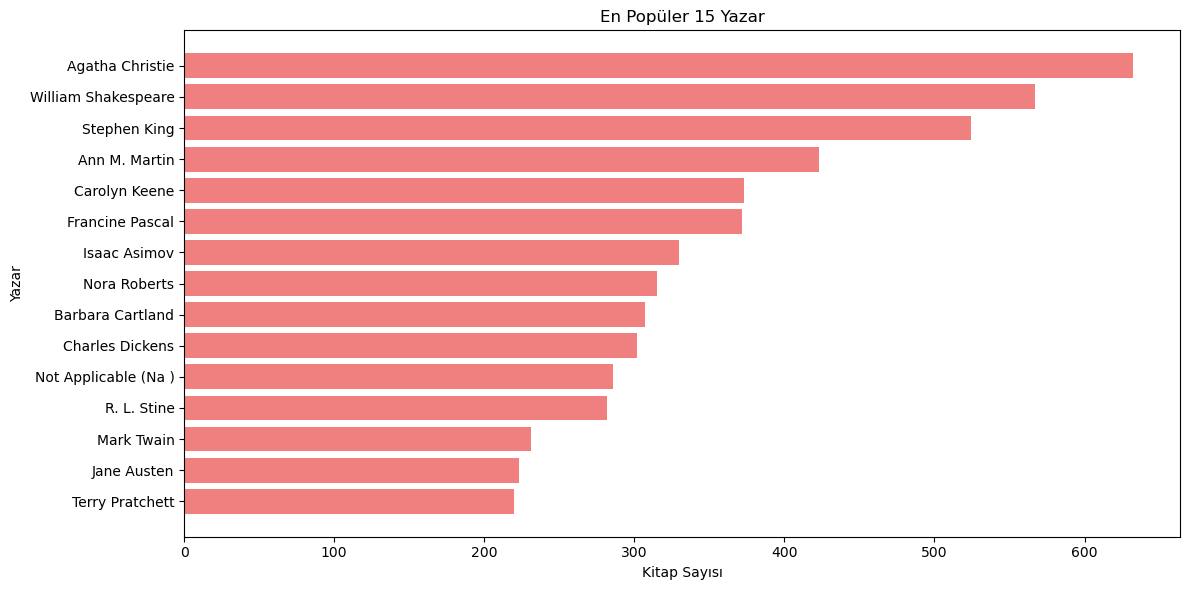

In [21]:
# 1. En popüler yazarlar
plt.figure(figsize=(12, 6))
data = populer_yazarlar.head(15).sort_values(by='kitap_sayisi', ascending=True)
plt.barh(data.index, data['kitap_sayisi'], color='#F08080')
plt.xlabel('Kitap Sayısı')
plt.ylabel('Yazar')
plt.title('En Popüler 15 Yazar')
plt.tight_layout()
plt.show()

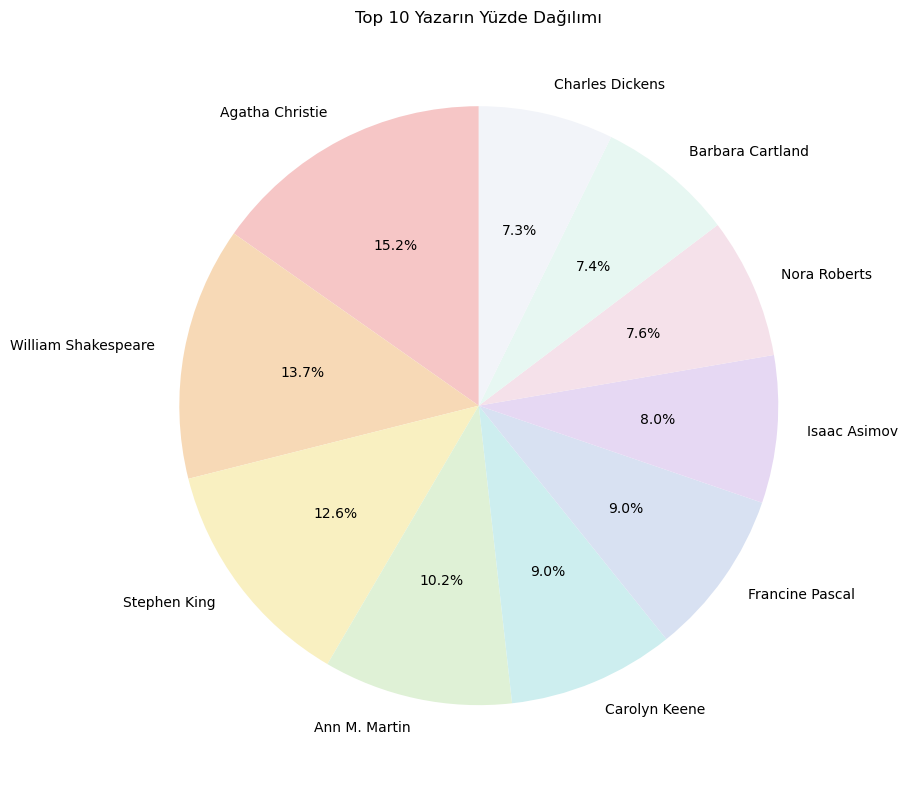

In [42]:
# Top 10 yazarların yüzde dağılımı
colors = ['#F6C6C6', '#F7D9B6', '#F9F0C1', '#DFF1D6', '#CDEEEF',
'#D8E1F2', '#E6D8F3', '#F5E1EA', '#E7F7F2', '#F2F4F9']
plt.figure(figsize=(12, 8))
populer_yazarlar.head(10)['yuzde'].plot(kind='pie', autopct='%1.1f%%',colors=colors, startangle=90)
plt.title('Top 10 Yazarın Yüzde Dağılımı')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [26]:
# Kitaplara göre grupla
kitap_istatistik = df.groupby('Book-Title').agg({'ISBN': 'count','Book-Author': 'first','Publisher': 'first'}).rename(columns={'ISBN': 'kitap_sayisi'})

In [27]:
# En popüler kitapları sırayla gösterelim;
populer_kitaplar = kitap_istatistik.sort_values(by='kitap_sayisi', ascending=False)

populer_kitaplar.head(20)

,kitap_sayisi,Book-Author,Publisher
Book-Title,,,
Selected Poems,27,William Carlos Williams,New Directions Publishing Corporation
Little Women,24,Louisa M. Atcott,Brimax Books Ltd
Wuthering Heights,21,EMILY BRONTE,Bantam
Adventures of Huckleberry Finn,20,Mark Twain,Globe Fearon
Dracula,20,Bram Stoker,Dorset Press
The Secret Garden,20,Frances Hodgson Burnett,Tor Books
Jane Eyre,19,Charlotte Bronte,New Amer Library Classics
The Night Before Christmas,18,Victoria Alexander,Love Spell
Pride and Prejudice,18,Jane Austen,Bantam


In [28]:
# Toplam kitap sayısı
toplam_kitap = populer_kitaplar['kitap_sayisi'].sum()

# Yüzde hesaplayalım
populer_kitaplar['yuzde'] = (populer_kitaplar['kitap_sayisi'] / toplam_kitap) * 100

In [29]:
# Sıralama (Ranking) ekle
populer_kitaplar['siralama'] = populer_kitaplar['yuzde'].rank(ascending=False)

In [30]:
#TAVSİYE EDİLEN KİTAPLAR
sonuc = populer_kitaplar.sort_values(by='siralama', ascending=True).head(15)
sonuc

,kitap_sayisi,Book-Author,Publisher,yuzde,siralama
Book-Title,,,,,
Selected Poems,27,William Carlos Williams,New Directions Publishing Corporation,0.009950,1.0
Little Women,24,Louisa M. Atcott,Brimax Books Ltd,0.008844,2.0
Wuthering Heights,21,EMILY BRONTE,Bantam,0.007739,3.0
Adventures of Huckleberry Finn,20,Mark Twain,Globe Fearon,0.007370,5.0
Dracula,20,Bram Stoker,Dorset Press,0.007370,5.0
The Secret Garden,20,Frances Hodgson Burnett,Tor Books,0.007370,5.0
Jane Eyre,19,Charlotte Bronte,New Amer Library Classics,0.007002,7.0
The Night Before Christmas,18,Victoria Alexander,Love Spell,0.006633,8.5
Pride and Prejudice,18,Jane Austen,Bantam,0.006633,8.5


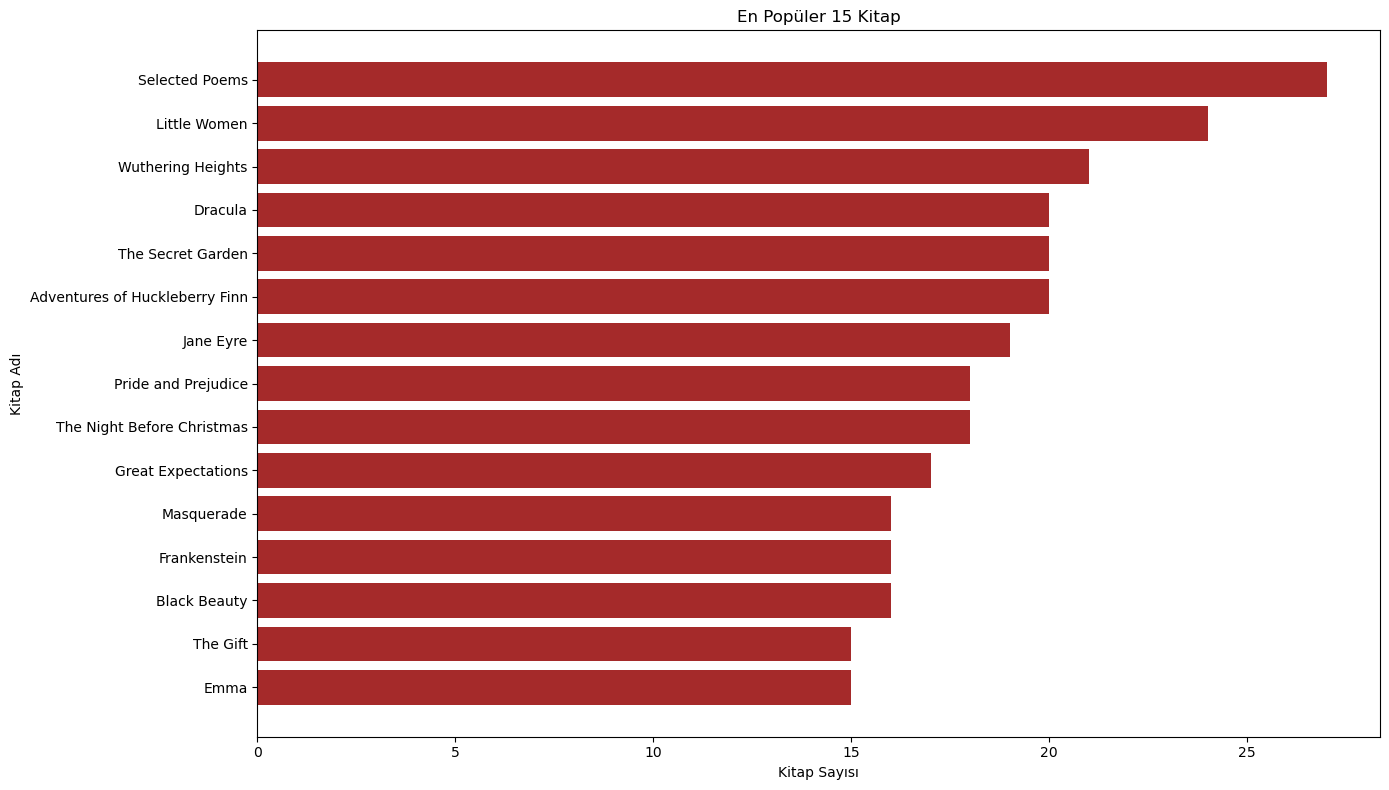

In [31]:
# En popüler kitaplar
plt.figure(figsize=(14, 8))
data = populer_kitaplar.head(15).sort_values(by='kitap_sayisi', ascending=True)
plt.barh(data.index, data['kitap_sayisi'], color='#A52A2A')
plt.xlabel('Kitap Sayısı')
plt.ylabel('Kitap Adı')
plt.title('En Popüler 15 Kitap')
plt.tight_layout()
plt.show()

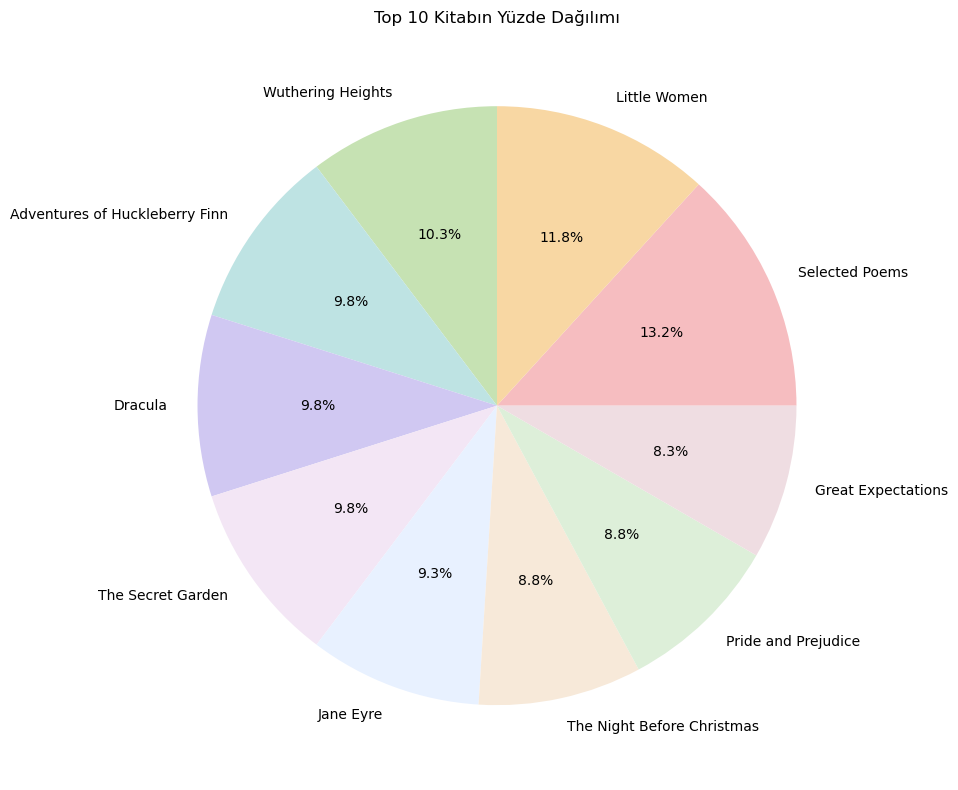

In [39]:
# Top 10 kitapların yüzde dağılımı
plt.figure(figsize=(12, 8))
colors = ['#F6BDC0', '#F8D7A3', '#C6E2B3', '#BEE3E3', '#D0C8F2',
'#F3E6F5', '#E8F1FF', '#F7E9D9', '#DDEFD9', '#EFDDE2'] # pastel/soft tonlar
populer_kitaplar.head(10)['yuzde'].plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.title('Top 10 Kitabın Yüzde Dağılımı')
plt.ylabel('')
plt.tight_layout()
plt.show()

Yapılan analizler sonucunda en çok talep gören kitaplar ve yazarlar belirlenmiş ve popülariteye göre sıralanarak kullanıcılar için bir öneri sistemi oluşturulmuştur.